In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('D:\\DataAnalysis\\Py_projects\\banking\\data\\processed\\clean_bank_transactions.csv')

In [89]:
df.dtypes

TransactionID                      object
CustomerID                         object
CustomerDOB                        object
CustGender                         object
CustLocation                       object
CustAccountBalance                float64
TransactionDate            datetime64[ns]
TransactionTime                    object
TransactionAmount (INR)           float64
TransactionDateTime        datetime64[ns]
TransactionHr                       int32
DaysOfWeek                         object
dtype: object

In [3]:
# Basic Business KPIs
print("Total Transactions:", len(df))
print("Total Customers:", df['CustomerID'].nunique())
print("Total Transaction value:", round(df['TransactionAmount (INR)'].sum(),2))
print("Average Transaction: ", round(df['TransactionAmount (INR)'].mean(),2))
print("Median Transaction:", df['TransactionAmount (INR)'].median())
print("Maximum Transaction:", df['TransactionAmount (INR)'].max())


Total Transactions: 1048567
Total Customers: 884265
Total Transaction value: 1650795731.57
Average Transaction:  1574.34
Median Transaction: 459.03
Maximum Transaction: 1560034.99


In [87]:
transaction_summary = pd.DataFrame({
                   'Metric':[
                            'Total Transactions',
                            'Unique Customers',
                            'Total Transaction Value',
                            'Average Transaction',
                            'Median Transaction',
                            'Maximum Transaction',
                            'Minimum Transaction'
                            ],
                    'Value':[
                            len(df),
                            df['CustomerID'].nunique(),
                            df['TransactionAmount (INR)'].sum(),
                            df['TransactionAmount (INR)'].mean(),
                            df['TransactionAmount (INR)'].median(),
                            df['TransactionAmount (INR)'].max(),
                            df['TransactionAmount (INR)'].min()
                            ]
                    })
transaction_summary

,Metric,Value
0,Total Transactions,1.048567e+06
1,Unique Customers,8.842650e+05
2,Total Transaction Value,1.650796e+09
3,Average Transaction,1.574335e+03
4,Median Transaction,4.590300e+02
5,Maximum Transaction,1.560035e+06
6,Minimum Transaction,0.000000e+00


In [5]:
daily_transaction = df.groupby('TransactionDate').agg(
                        transactions = ('TransactionID', 'count'), 
                        transaction_value = ('TransactionAmount (INR)', 'sum',),
                        customers = ('CustomerID', 'nunique'),
                        ).reset_index()

daily_transaction.head()
                

,TransactionDate,transactions,transaction_value,customers
0,2016-08-01,20438,29801816.34,20356
1,2016-08-02,20948,30467503.29,20872
2,2016-08-03,20615,31149483.67,20546
3,2016-08-04,20682,35722718.64,20610
4,2016-08-05,21112,34833933.12,21029


In [6]:
daily_transaction.describe()

,transactions,transaction_value,customers
count,55.000000,5.500000e+01,55.000000
mean,19064.854545,3.001447e+07,18997.363636
std,6392.185381,1.070057e+07,6362.636410
min,3.000000,1.067000e+03,3.000000
25%,18286.000000,2.771479e+07,18218.500000
50%,20753.000000,3.067903e+07,20684.000000
75%,21828.000000,3.450596e+07,21757.500000
max,27261.000000,4.752723e+07,27135.000000


In [7]:
# Top 10 Transaction Value
daily_transaction.nlargest(10, 'transaction_value')


,TransactionDate,transactions,transaction_value,customers
5,2016-08-06,26585,47527227.82,26475
34,2016-09-04,26564,46118447.52,26452
13,2016-08-14,25596,45732820.10,25473
6,2016-08-07,27261,45727772.63,27135
33,2016-09-03,26431,45312089.56,26333
12,2016-08-13,26921,44645472.34,26786
14,2016-08-15,24171,44313092.06,24077
41,2016-09-11,25454,41668308.96,25345
40,2016-09-10,25761,39988234.58,25674
32,2016-09-02,22839,36649840.64,22773


In [8]:
# Days when most transactions taken place
daily_transaction.nlargest(10, 'transactions')

,TransactionDate,transactions,transaction_value,customers
6,2016-08-07,27261,45727772.63,27135
12,2016-08-13,26921,44645472.34,26786
5,2016-08-06,26585,47527227.82,26475
34,2016-09-04,26564,46118447.52,26452
33,2016-09-03,26431,45312089.56,26333
40,2016-09-10,25761,39988234.58,25674
13,2016-08-14,25596,45732820.10,25473
41,2016-09-11,25454,41668308.96,25345
14,2016-08-15,24171,44313092.06,24077
20,2016-08-21,22986,34301751.22,22896


In [9]:
daily_transaction.nsmallest(5, 'transactions')

,TransactionDate,transactions,transaction_value,customers
53,2016-10-16,3,1067.00,3
52,2016-09-30,1951,3316668.50,1951
48,2016-09-23,3485,4733700.44,3484
54,2016-10-21,3656,7663951.63,3651
47,2016-09-22,6971,12746612.34,6969


In [10]:
df['TransactionDate'].max()

'2016-10-21'

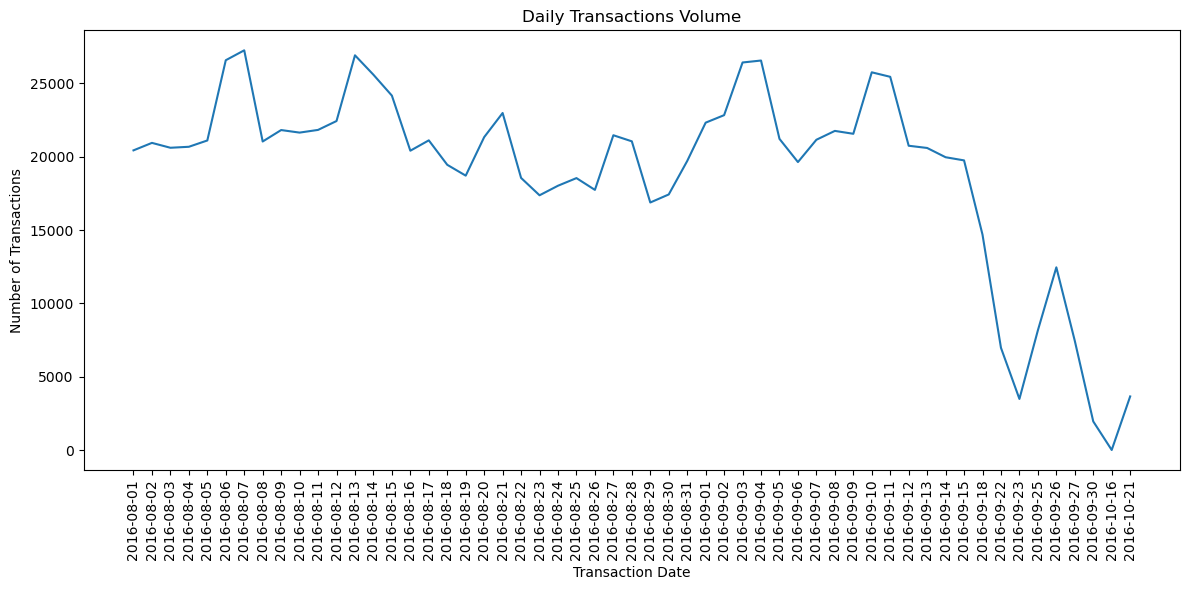

In [11]:
# Plot Daily Transaction volume
plt.figure(figsize=(12,6))
plt.plot(daily_transaction['TransactionDate'], 
         daily_transaction['transactions']
        )
plt.xlabel('Transaction Date')
plt.ylabel('Number of Transactions')
plt.title('Daily Transactions Volume')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('daily_transaction_vol.png', dpi=300, bbox_inches='tight')
plt.show()


         


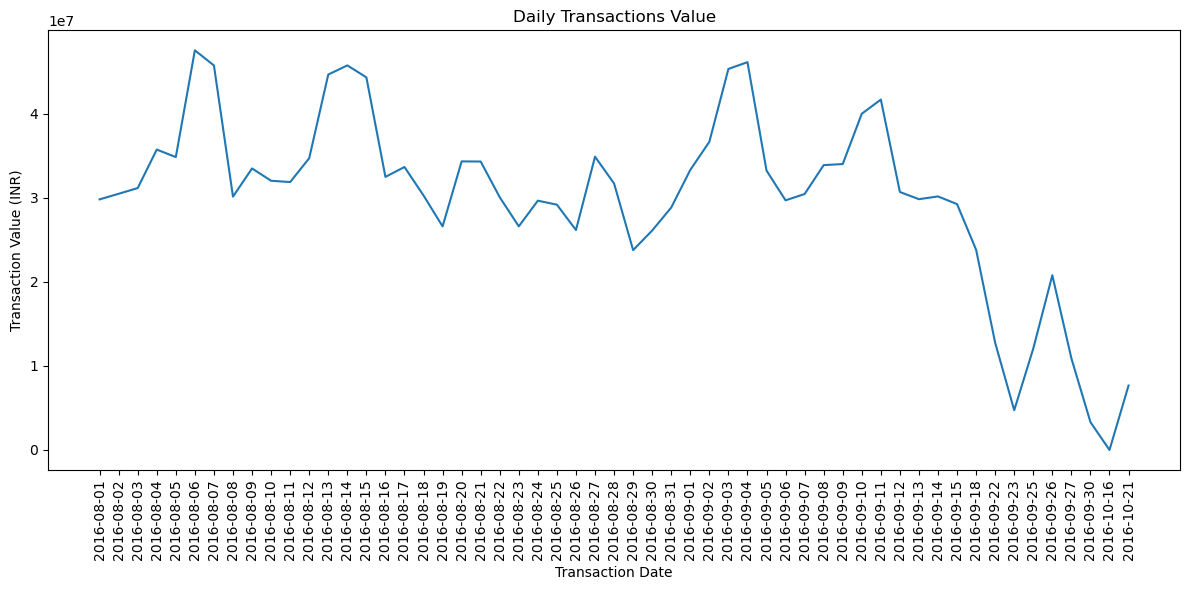

In [12]:
# Plot Daily Transaction value
plt.figure(figsize=(12,6))
plt.plot(daily_transaction['TransactionDate'], 
         daily_transaction['transaction_value']
        )
plt.xlabel('Transaction Date')
plt.ylabel('Transaction Value (INR)')
plt.title('Daily Transactions Value')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('daily_transactions_value.png', dpi=300, bbox_inches='tight')
plt.show()

In [96]:
df['TransactionTime'].dtype


dtype('O')

In [25]:
df['TransactionDateTime'] = pd.to_datetime(df['TransactionDateTime'], format='%Y-%m-%d %H:%M:%S')
df['TransactionDateTime'].dtype

dtype('<M8[ns]')

In [26]:
# Transaction Activity by hour
df['TransactionHr'] = df['TransactionDateTime'].dt.hour
hourly_activity = df.groupby('TransactionHr').agg(
                        transactions = ('TransactionID', 'count'), 
                        transaction_value = ('TransactionAmount (INR)', 'sum',),
                        avg_transaction = ('TransactionAmount (INR)', 'mean'),
                        ).reset_index()
hourly_activity.head()

,TransactionHr,transactions,transaction_value,avg_transaction
0,0,17977,24220958.52,1347.330396
1,1,8851,10746828.61,1214.193719
2,2,5553,6505162.85,1171.468188
3,3,4720,5067690.40,1073.663220
4,4,4571,4536081.19,992.360794


In [27]:
hourly_activity.nlargest(5, 'transactions')

,TransactionHr,transactions,transaction_value,avg_transaction
20,20,97053,1.471459e+08,1516.139846
19,19,94396,1.488385e+08,1576.746017
21,21,80105,1.076796e+08,1344.231309
18,18,79332,1.463452e+08,1844.718811
17,17,69222,1.350766e+08,1951.353755


In [30]:
hourly_activity.nlargest(5, 'transaction_value')


,TransactionHr,transactions,transaction_value,avg_transaction
19,19,94396,1.488385e+08,1576.746017
20,20,97053,1.471459e+08,1516.139846
18,18,79332,1.463452e+08,1844.718811
17,17,69222,1.350766e+08,1951.353755
16,16,64357,1.223665e+08,1901.369947


In [29]:
hourly_activity.sort_values('TransactionHr')

,TransactionHr,transactions,transaction_value,avg_transaction
0,0,17977,2.422096e+07,1347.330396
1,1,8851,1.074683e+07,1214.193719
2,2,5553,6.505163e+06,1171.468188
3,3,4720,5.067690e+06,1073.663220
4,4,4571,4.536081e+06,992.360794
5,5,5359,5.196658e+06,969.706688
6,6,8218,8.667636e+06,1054.713584
7,7,14579,1.520289e+07,1042.793505
8,8,23523,2.447080e+07,1040.292667
9,9,33098,3.945479e+07,1192.059638


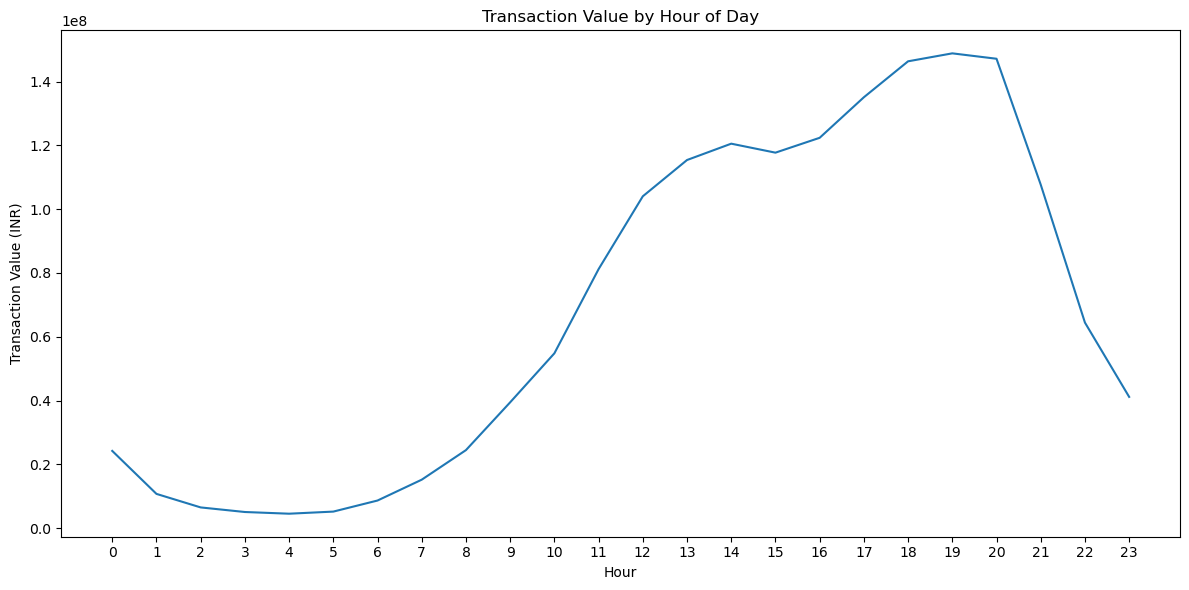

In [31]:
# Transaction Value by Hour of Day
plt.figure(figsize=(12,6))
plt.plot(hourly_activity['TransactionHr'], 
         hourly_activity['transaction_value']
        )
plt.xlabel('Hour')
plt.ylabel('Transaction Value (INR)')
plt.title('Transaction Value by Hour of Day')
plt.xticks(hourly_activity['TransactionHr'])
plt.tight_layout()
# plt.savefig('hourly_transactions_value.png', dpi=300, bbox_inches='tight')
plt.show()

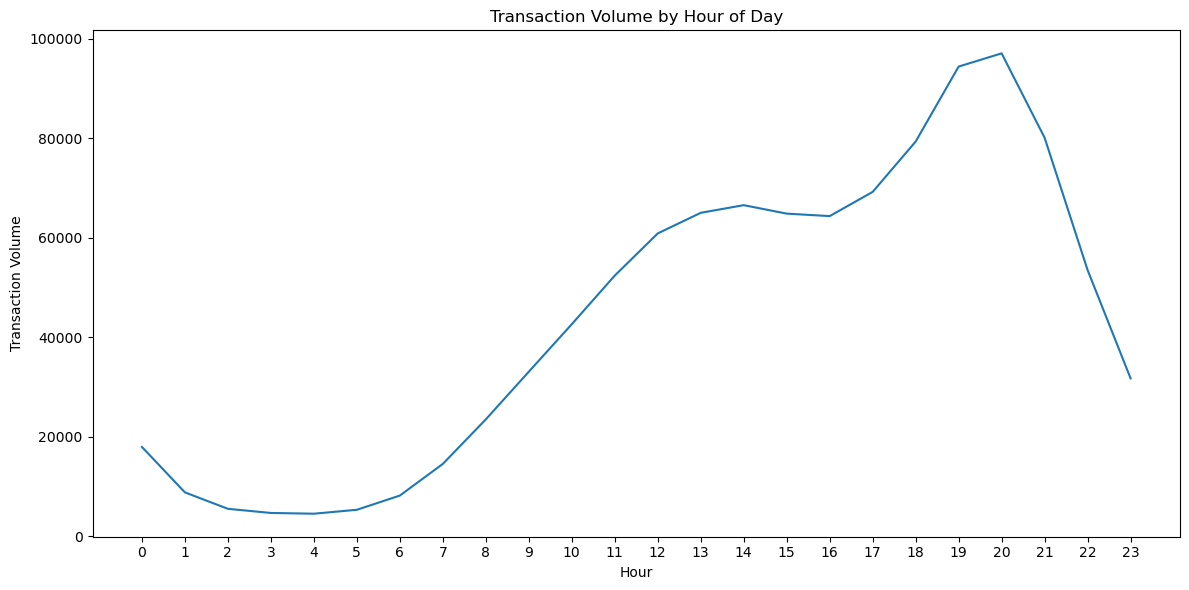

In [32]:
# Transaction Volume by Hour of Day
plt.figure(figsize=(12,6))
plt.plot(hourly_activity['TransactionHr'], 
        hourly_activity['transactions']
        )
plt.xlabel('Hour')
plt.ylabel('Transaction Volume')
plt.title('Transaction Volume by Hour of Day')
plt.xticks(hourly_activity['TransactionHr'])
plt.tight_layout()
# plt.savefig('hourly_transactions_vol.png', dpi=300, bbox_inches='tight')
plt.show()

In [33]:
df['TransactionDate'] = df['TransactionDateTime'].dt.normalize()
df['TransactionDate'].max()

Timestamp('2016-10-21 00:00:00')

In [34]:

df['DaysOfWeek'] = df['TransactionDate'].dt.day_name()

In [35]:
weekly_transactions = df.groupby('DaysOfWeek').agg(
                        transactions = ('TransactionID', 'count'), 
                        transaction_value = ('TransactionAmount (INR)', 'sum'),
                        avg_transaction = ('TransactionAmount (INR)', 'mean'),
                        customers = ('CustomerID', 'nunique')
                        ).reindex(['Monday', 'Tuesday', 'Wednesday',
                          'Thursday', 'Friday', 'Saturday', 'Sunday']).reset_index()

weekly_transactions.head(10)

,DaysOfWeek,transactions,transaction_value,avg_transaction,customers
0,Monday,155525,2.427556e+08,1560.878179,151628
1,Tuesday,145677,2.195351e+08,1506.998882,142177
2,Wednesday,142252,2.158911e+08,1517.666306,138859
3,Thursday,151331,2.361853e+08,1560.719688,147516
4,Friday,133505,2.086427e+08,1562.807787,130499
5,Saturday,148506,2.466678e+08,1660.995423,144817
6,Sunday,171771,2.811183e+08,1636.587656,166847


In [36]:
weekly_summary = df.groupby('DaysOfWeek').agg(
                        transactions = ('TransactionID', 'count'), 
                        transaction_value = ('TransactionAmount (INR)', 'sum'),
                        customers = ('CustomerID', 'nunique'),
                        days = ('TransactionDate', 'nunique')
                        ).reindex(['Monday', 'Tuesday', 'Wednesday',
                          'Thursday', 'Friday', 'Saturday', 'Sunday']).reset_index()

weekly_summary['avg_transaction_per_day'] = (weekly_summary['transactions'] / weekly_summary['days'])
weekly_summary['avg_transaction_value_per_day'] = (weekly_summary['transaction_value'] / weekly_summary['days'])

weekly_summary



,DaysOfWeek,transactions,transaction_value,customers,days,avg_transaction_per_day,avg_transaction_value_per_day
0,Monday,155525,2.427556e+08,151628,8,19440.625000,3.034445e+07
1,Tuesday,145677,2.195351e+08,142177,8,18209.625000,2.744188e+07
2,Wednesday,142252,2.158911e+08,138859,7,20321.714286,3.084158e+07
3,Thursday,151331,2.361853e+08,147516,8,18916.375000,2.952316e+07
4,Friday,133505,2.086427e+08,130499,9,14833.888889,2.318252e+07
5,Saturday,148506,2.466678e+08,144817,6,24751.000000,4.111130e+07
6,Sunday,171771,2.811183e+08,166847,9,19085.666667,3.123537e+07


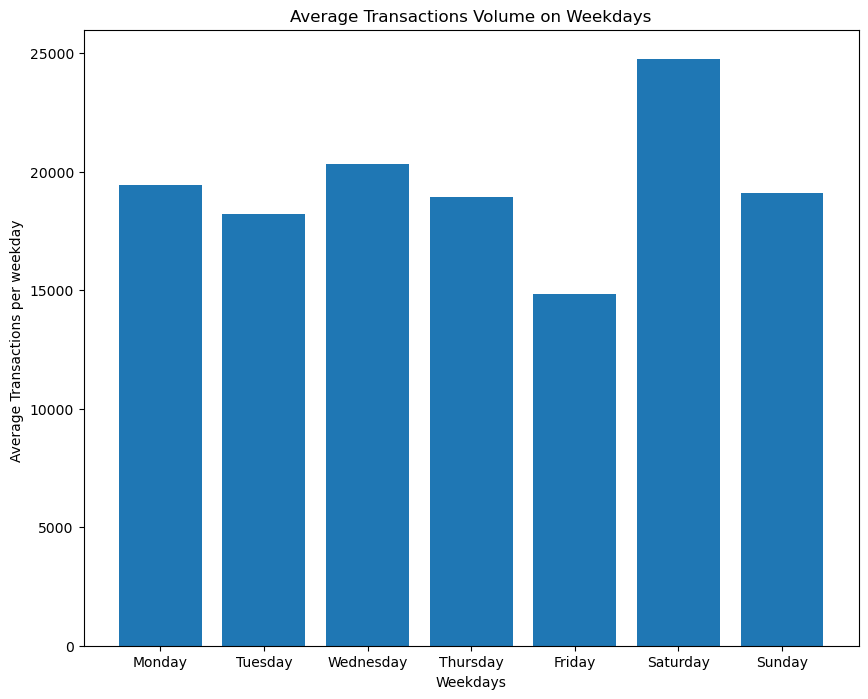

In [37]:
# Average Daily Transaction Volume by Day of Week
plt.figure(figsize=(10, 8))

plt.bar(
    weekly_summary['DaysOfWeek'],
    weekly_summary['avg_transaction_per_day']
)

plt.xlabel('Weekdays')
plt.ylabel('Average Transactions per weekday ')
plt.title('Average Transactions Volume on Weekdays')
plt.xticks(weekly_summary['DaysOfWeek'])
plt.savefig('avg_transac_vol.png', dpi=300, bbox_inches='tight')
plt.show() 

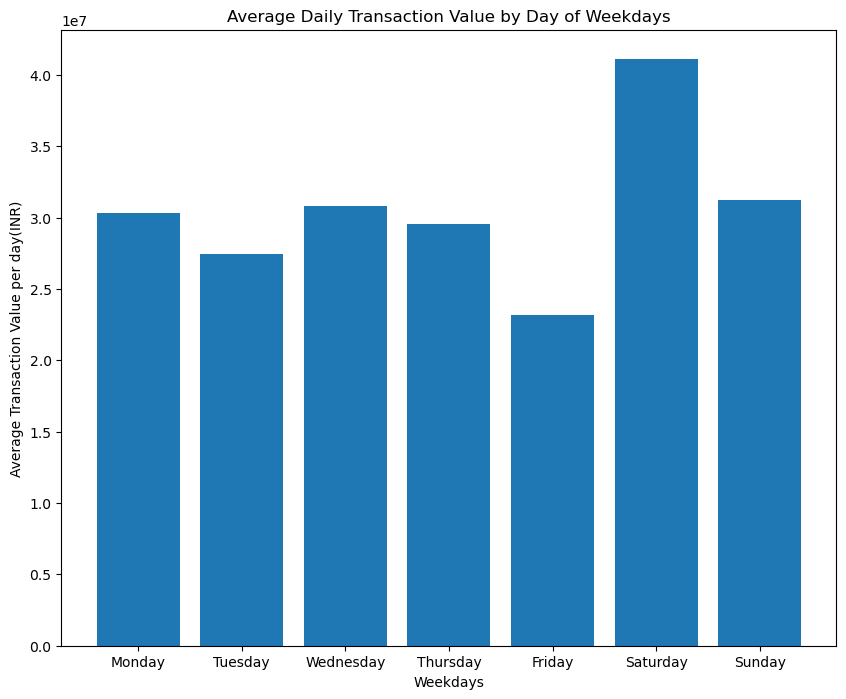

In [38]:
# Average Daily Transaction Value by Day of Week
plt.figure(figsize=(10, 8))

plt.bar(
    weekly_summary['DaysOfWeek'],
    weekly_summary['avg_transaction_value_per_day']
)

plt.xlabel('Weekdays')
plt.ylabel('Average Transaction Value per day(INR)')
plt.title('Average Daily Transaction Value by Day of Weekdays')
plt.xticks(weekly_summary['DaysOfWeek'])
plt.savefig('avg_transac_value.png', dpi=300, bbox_inches='tight')
plt.show() 

In [39]:
customer_activity = df.groupby('CustomerID').agg(
                        transactions = ('TransactionID', 'count'), 
                        transaction_value = ('TransactionAmount (INR)', 'sum'),
                        avg_transaction = ('TransactionAmount (INR)', 'mean')
).reset_index()
customer_activity.sort_values('transactions', ascending=False).head()

,CustomerID,transactions,transaction_value,avg_transaction
497427,C5533885,6,2854.54,475.756667
570274,C6222360,6,5825.00,970.833333
364929,C4327447,6,12027.00,2004.500000
330645,C4021562,6,9796.03,1632.671667
482282,C5418253,6,5722.78,953.796667


In [40]:
customer_activity.nlargest(10, 'transactions')

,CustomerID,transactions,transaction_value,avg_transaction
4602,C1026833,6,3336.00,556.000000
11856,C1113684,6,37873.00,6312.166667
83551,C1736254,6,5554.50,925.750000
244659,C3226689,6,14758.39,2459.731667
330645,C4021562,6,9796.03,1632.671667
364929,C4327447,6,12027.00,2004.500000
383027,C4513786,6,12800.00,2133.333333
482282,C5418253,6,5722.78,953.796667
496742,C5531319,6,8503.00,1417.166667
497427,C5533885,6,2854.54,475.756667


In [41]:
customer_activity.nlargest(10, 'avg_transaction')

,CustomerID,transactions,transaction_value,avg_transaction
690030,C7319271,1,1560034.99,1560034.99
620917,C6677159,1,1380002.88,1380002.88
346972,C4141768,1,991132.22,991132.22
93016,C1830891,1,720001.16,720001.16
609110,C6549785,1,600008.32,600008.32
443726,C5036642,1,600003.45,600003.45
365101,C4328064,1,569500.27,569500.27
47597,C1425138,1,561001.00,561001.00
529812,C5833636,1,557000.73,557000.73
718602,C7549492,1,543699.36,543699.36


In [42]:
customer_activity['transactions'].value_counts().sort_index().head(20)

transactions
1    740653
2    124960
3     16789
4      1702
5       147
6        14
Name: count, dtype: int64

In [43]:
repeat_customers = (
    customer_activity['transactions'] > 1
).sum()

onetime_customers = (
    customer_activity['transactions'] == 1
).sum()

print("One-time customers:", onetime_customers)
print("Repeat customers:", repeat_customers)

print("One-time %:",
      round(onetime_customers / len(customer_activity) * 100), 2)

print("Repeat %:",
      round(repeat_customers / len(customer_activity) * 100), 2)

One-time customers: 740653
Repeat customers: 143612
One-time %: 84 2
Repeat %: 16 2


In [44]:
import numpy as np
customer_activity['customer_type'] = np.where(
    customer_activity['transactions'] == 1,
    'Onetime',
    'Repeat'
)

In [45]:
cust_type_summary = (
    customer_activity
    .groupby('customer_type')
    .agg(
        customers=('CustomerID', 'count'),
        transactions=('transactions', 'sum'),
        total_value=('transaction_value', 'sum'),
        avg_customer_value=('transaction_value', 'mean')
    )
    .reset_index()
)

cust_type_summary

,customer_type,customers,transactions,total_value,avg_customer_value
0,Onetime,740653,740653,1.166862e+09,1575.450840
1,Repeat,143612,307914,4.839333e+08,3369.727743


In [46]:
customer_frequency = (
    customer_activity
    .groupby('transactions')
    .agg(
        customers=('CustomerID', 'count'),
        total_value=('transaction_value', 'sum'),
        avg_customer_value=('transaction_value', 'mean'),
        total_transactions=('transactions', 'sum')
    )
    .reset_index()
)

customer_frequency

,transactions,customers,total_value,avg_customer_value,total_transactions
0,1,740653,1.166862e+09,1575.450840,740653
1,2,124960,3.926476e+08,3142.186370,249920
2,3,16789,7.913407e+07,4713.447266,50367
3,4,1702,1.068457e+07,6277.656657,6808
4,5,147,1.315567e+06,8949.432585,735
5,6,14,1.515275e+05,10823.391429,84


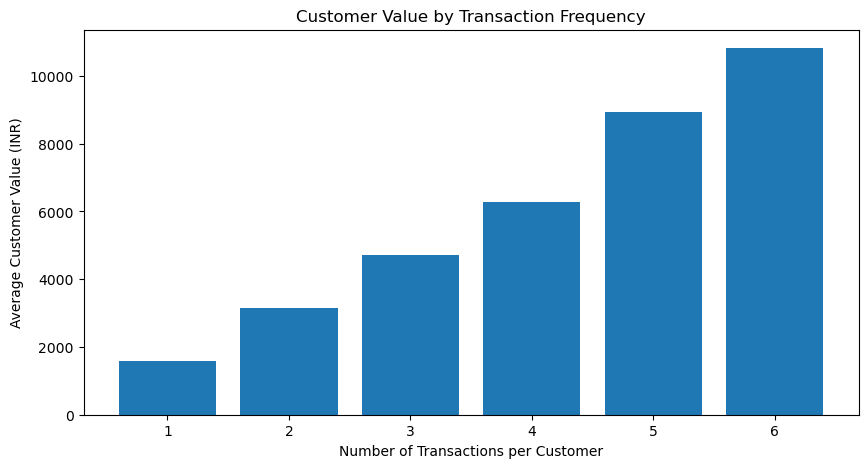

In [47]:
plt.figure(figsize=(10, 5))

plt.bar(
    customer_frequency['transactions'],
    customer_frequency['avg_customer_value']
)

plt.xlabel('Number of Transactions per Customer')
plt.ylabel('Average Customer Value (INR)')
plt.title('Customer Value by Transaction Frequency')
plt.xticks(customer_frequency['transactions'])
plt.savefig('customer_frequency.png', dpi=300, bbox_inches='tight')
plt.show()

In [48]:
customer_activity[
    customer_activity['transactions'] > 1
].nlargest(10, 'transaction_value')

,CustomerID,transactions,transaction_value,avg_transaction,customer_type
787789,C8217728,2,724472.00,362236.000000,Repeat
277986,C3528755,4,550972.34,137743.085000,Repeat
713603,C7525532,3,453000.00,151000.000000,Repeat
517411,C5727148,2,378615.46,189307.730000,Repeat
630203,C6741078,2,378205.07,189102.535000,Repeat
317225,C3912568,2,352100.00,176050.000000,Repeat
547832,C6019474,3,317827.25,105942.416667,Repeat
276128,C3521982,2,309093.00,154546.500000,Repeat
813135,C8429762,2,302000.00,151000.000000,Repeat
883154,C9067184,2,300050.00,150025.000000,Repeat


In [49]:
customer_activity[
    customer_activity['transactions'] > 1
].nlargest(10, 'avg_transaction')

,CustomerID,transactions,transaction_value,avg_transaction,customer_type
787789,C8217728,2,724472.00,362236.000,Repeat
517411,C5727148,2,378615.46,189307.730,Repeat
630203,C6741078,2,378205.07,189102.535,Repeat
317225,C3912568,2,352100.00,176050.000,Repeat
276128,C3521982,2,309093.00,154546.500,Repeat
713603,C7525532,3,453000.00,151000.000,Repeat
813135,C8429762,2,302000.00,151000.000,Repeat
883154,C9067184,2,300050.00,150025.000,Repeat
69494,C1625456,2,286400.12,143200.060,Repeat
277986,C3528755,4,550972.34,137743.085,Repeat


In [50]:
customer_activity['transaction_value'].describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
)

count    8.842650e+05
mean     1.866856e+03
std      7.207210e+03
min      0.000000e+00
50%      5.368000e+02
75%      1.500000e+03
90%      3.577000e+03
95%      6.350000e+03
99%      2.351944e+04
max      1.560035e+06
Name: transaction_value, dtype: float64

In [51]:
df.head()


,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR),TransactionDateTime,TransactionHr,DaysOfWeek
0,T1,C5841053,1994-10-01,F,JAMSHEDPUR,17819.05,2016-08-02,14:32:07,25.0,2016-08-02 14:32:07,14,Tuesday
1,T2,C2142763,NaN,M,JHAJJAR,2270.69,2016-08-02,14:18:58,27999.0,2016-08-02 14:18:58,14,Tuesday
2,T3,C4417068,1996-11-26,F,MUMBAI,17874.44,2016-08-02,14:27:12,459.0,2016-08-02 14:27:12,14,Tuesday
3,T4,C5342380,NaN,F,MUMBAI,866503.21,2016-08-02,14:27:14,2060.0,2016-08-02 14:27:14,14,Tuesday
4,T5,C9031234,1988-03-24,F,NAVI MUMBAI,6714.43,2016-08-02,18:11:56,1762.5,2016-08-02 18:11:56,18,Tuesday


In [52]:
# Location Analysis
location_analysis = df.groupby('CustLocation').agg(
            transaction_value= ('TransactionAmount (INR)','sum'),
            transaction_vol = ('TransactionID', 'count'),
            customers = ('CustomerID', 'nunique'),
            avg_transaction_val = ('TransactionAmount (INR)', 'mean')
            ).reset_index()


location_analysis.sort_values('transaction_value', ascending=False).head(10)
            
   

,CustLocation,transaction_value,transaction_vol,customers,avg_transaction_val
5268,MUMBAI,1.796861e+08,103595,101729,1734.505689
5792,NEW DELHI,1.607059e+08,84928,83564,1892.259948
772,BANGALORE,1.184248e+08,81555,80347,1452.085624
3083,GURGAON,1.120947e+08,73818,72856,1518.527926
2075,DELHI,1.062249e+08,71019,70067,1495.725647
4268,KOLKATA,6.060031e+07,19974,19874,3033.959657
1603,CHENNAI,4.463782e+07,30009,29823,1487.481137
5888,NOIDA,4.446343e+07,32784,32570,1356.254060
6719,PUNE,3.959035e+07,25851,25710,1531.482293
3394,HYDERABAD,3.617739e+07,23049,22929,1569.586291


In [53]:
#Top 10 locations By AVG Transaction Value(minimum 100 transactions)

location_avg = location_analysis[location_analysis['transaction_vol'] >= 100].sort_values('avg_transaction_val', ascending=False)
location_avg.head(10)


,CustLocation,transaction_value,transaction_vol,customers,avg_transaction_val
8686,TRICHUR,1086573.70,101,101,10758.155446
2224,DHURI,1285620.03,185,185,6949.297459
4834,MANDI GOBINDGARH,903095.51,133,133,6790.191805
7093,RIYADH,642829.74,100,100,6428.297400
2162,DHANBAD,7002394.53,1105,1103,6337.008624
266,ALLAHABAD,11729379.42,1972,1968,5947.961166
2455,DUBAI,2518733.37,492,492,5119.376768
139,ABU DHABI,711837.61,145,144,4909.224897
7704,SHARJAH,785268.86,161,161,4877.446335
7842,SINGAPORE,848197.94,184,184,4609.771413


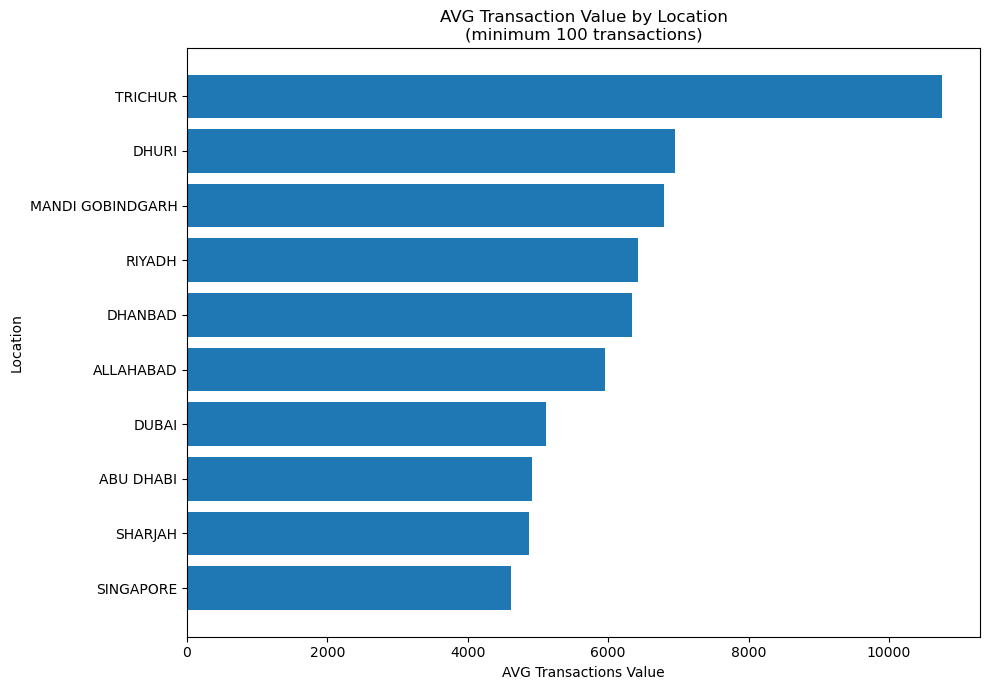

In [54]:
#Top 10 locations By AVG Transaction Value(minimum 100 transactions)
top10_location = location_avg.head(10)
plt.figure(figsize=(10, 7))

plt.barh(
    top10_location['CustLocation'],
    top10_location['avg_transaction_val']
)

plt.xlabel('AVG Transactions Value')
plt.ylabel('Location')
plt.title('AVG Transaction Value by Location\n(minimum 100 transactions)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('top10_loc_by_avg_val.png', dpi=300, bbox_inches='tight')
plt.show()

In [55]:
location_analysis.sort_values('transaction_value', ascending=False).head(10)

,CustLocation,transaction_value,transaction_vol,customers,avg_transaction_val
5268,MUMBAI,1.796861e+08,103595,101729,1734.505689
5792,NEW DELHI,1.607059e+08,84928,83564,1892.259948
772,BANGALORE,1.184248e+08,81555,80347,1452.085624
3083,GURGAON,1.120947e+08,73818,72856,1518.527926
2075,DELHI,1.062249e+08,71019,70067,1495.725647
4268,KOLKATA,6.060031e+07,19974,19874,3033.959657
1603,CHENNAI,4.463782e+07,30009,29823,1487.481137
5888,NOIDA,4.446343e+07,32784,32570,1356.254060
6719,PUNE,3.959035e+07,25851,25710,1531.482293
3394,HYDERABAD,3.617739e+07,23049,22929,1569.586291


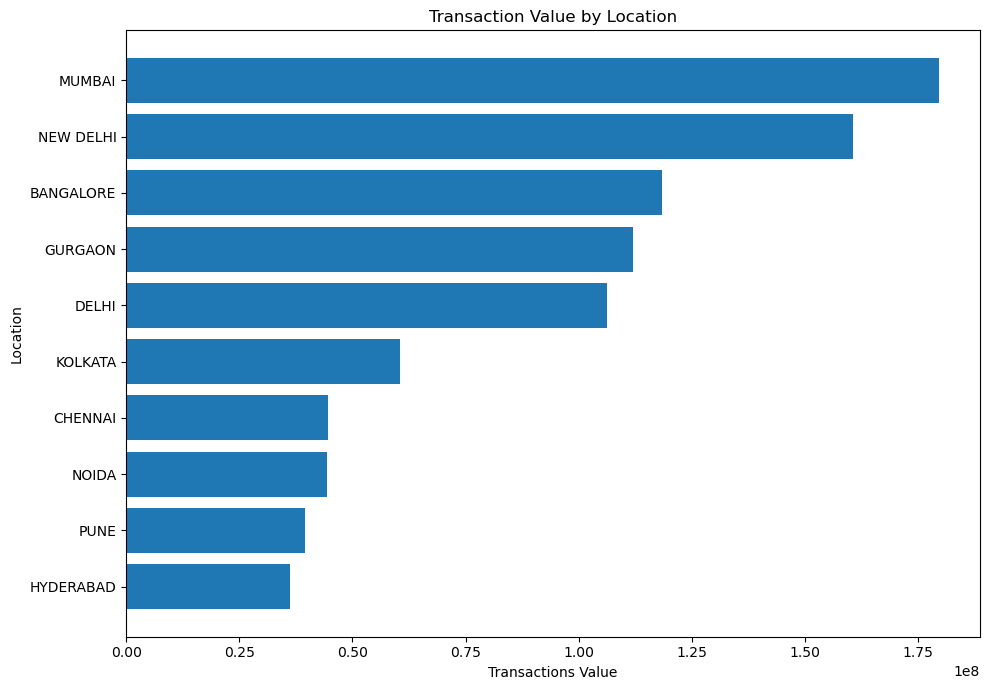

In [56]:
#Top 10 locations By Transaction Value
top10_location = location_analysis.sort_values('transaction_value', ascending=False).head(10)
plt.figure(figsize=(10, 7))

plt.barh(
    top10_location['CustLocation'],
    top10_location['transaction_value']
)

plt.xlabel('Transactions Value')
plt.ylabel('Location')
plt.title('Transaction Value by Location')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('top10_loc_by_trans_val.png', dpi=300, bbox_inches='tight')
plt.show()

In [57]:
gender_analysis = df.groupby('CustGender').agg(
            transaction_value= ('TransactionAmount (INR)','sum'),
            transaction_vol = ('TransactionID', 'count'),
            customers = ('CustomerID', 'nunique'),
            avg_transaction_val = ('TransactionAmount (INR)', 'mean')
            ).reset_index()

gender_analysis


,CustGender,transaction_value,transaction_vol,customers,avg_transaction_val
0,F,4.668110e+08,281936,268662,1655.733753
1,M,1.181645e+09,765530,674701,1543.564378
2,T,3.250000e+04,1,1,32500.000000
3,Unknown,2.307442e+06,1100,1100,2097.674564


In [58]:
cust_analysis = df.groupby('CustomerID', as_index=False).agg(
    transaction_count=('TransactionID', 'count'),
    total_transaction_value=('TransactionAmount (INR)', 'sum'),
    avg_transaction_value=('TransactionAmount (INR)', 'mean'),
    max_transaction_value=('TransactionAmount (INR)', 'max'),
    avg_account_balance=('CustAccountBalance', 'mean')
)

cust_analysis.head(10)

,CustomerID,transaction_count,total_transaction_value,avg_transaction_value,max_transaction_value,avg_account_balance
0,C1010011,2,5106.0,2553.0,4750.0,76340.635
1,C1010012,1,1499.0,1499.0,1499.0,24204.490
2,C1010014,2,1455.0,727.5,1205.0,100112.950
3,C1010018,1,30.0,30.0,30.0,496.180
4,C1010024,1,5000.0,5000.0,5000.0,87058.650
5,C1010028,1,557.0,557.0,557.0,296828.370
6,C1010031,2,1864.0,932.0,1460.0,5200.155
7,C1010035,2,750.0,375.0,700.0,192648.755
8,C1010036,1,208.0,208.0,208.0,355430.170
9,C1010037,1,19680.0,19680.0,19680.0,95859.170


In [59]:
cust_analysis = cust_analysis.sort_values('total_transaction_value', ascending=False).reset_index(drop=True)


In [60]:
cust_analysis['cumulative_trans_val'] = cust_analysis['total_transaction_value'].cumsum()
total_value = cust_analysis['total_transaction_value'].sum()
cust_analysis['cumulative_pct'] = round(cust_analysis['cumulative_trans_val']/total_value *100,2)
cust_analysis.head(20)

,CustomerID,transaction_count,total_transaction_value,avg_transaction_value,max_transaction_value,avg_account_balance,cumulative_trans_val,cumulative_pct
0,C7319271,1,1560034.99,1560034.990,1560034.99,4.248789e+04,1560034.99,0.09
1,C6677159,1,1380002.88,1380002.880,1380002.88,9.866033e+04,2940037.87,0.18
2,C4141768,1,991132.22,991132.220,991132.22,8.360810e+04,3931170.09,0.24
3,C8217728,2,724472.00,362236.000,724122.00,3.069715e+07,4655642.09,0.28
4,C1830891,1,720001.16,720001.160,720001.16,1.417765e+04,5375643.25,0.33
5,C6549785,1,600008.32,600008.320,600008.32,2.919846e+04,5975651.57,0.36
6,C5036642,1,600003.45,600003.450,600003.45,1.362946e+05,6575655.02,0.40
7,C4328064,1,569500.27,569500.270,569500.27,3.873517e+04,7145155.29,0.43
8,C1425138,1,561001.00,561001.000,561001.00,9.324350e+03,7706156.29,0.47
9,C5833636,1,557000.73,557000.730,557000.73,1.438837e+05,8263157.02,0.50


In [61]:
cust_analysis = cust_analysis.sort_values('total_transaction_value', ascending=False).reset_index(drop=True)
n_customer = len(cust_analysis)

pareto = {}
for pct in [1, 5, 10, 20]:
    n = int(n_customer*pct/100)
    value = cust_analysis.head(n)['total_transaction_value'].sum()
    pareto[pct] = round(value / total_value*100)

pareto


{1: 27, 5: 51, 10: 63, 20: 77}

In [62]:
cust_analysis[
        ['transaction_count', 'total_transaction_value', 'avg_transaction_value', 'avg_account_balance']
            ].describe(percentiles=[.25, .50, .75, .90, .95, .99])

,transaction_count,total_transaction_value,avg_transaction_value,avg_account_balance
count,884265.000000,8.842650e+05,8.842650e+05,8.826000e+05
mean,1.185806,1.866856e+03,1.574781e+03,1.151579e+05
std,0.450683,7.207210e+03,6.443050e+03,8.012311e+05
min,1.000000,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.000000,2.000000e+02,1.920000e+02,5.590570e+03
50%,1.000000,5.368000e+02,5.000000e+02,1.871484e+04
75%,1.000000,1.500000e+03,1.248000e+03,6.177764e+04
90%,2.000000,3.577000e+03,2.955000e+03,2.036360e+05
95%,2.000000,6.350000e+03,5.189914e+03,4.169304e+05
99%,3.000000,2.351944e+04,1.998000e+04,1.540084e+06


In [63]:
cust_analysis['value_segment'] = pd.qcut(cust_analysis['total_transaction_value'], 
                                         q = [.25, .50, .75, .90, .99, 1],
                                         labels =[
                                                'Low Value',
                                                'Medium Value',
                                                'High Value',
                                                'Very High Value',
                                                'Top 1%'
                                                 ],
                                          duplicates = 'drop'
                                        )

value_segments = cust_analysis.groupby('value_segment',  observed = True).agg(
   total_transaction_value = ('total_transaction_value', 'sum'),
   avg_transaction_value = ('avg_transaction_value', 'mean'),
   avg_account_balance = ('avg_account_balance','mean'),
   customers = ('CustomerID', 'count') 
).reset_index()

value_segments
                                         

,value_segment,total_transaction_value,avg_transaction_value,avg_account_balance,customers
0,Low Value,7.791707e+07,324.461222,74689.639242,227574
1,Medium Value,2.076970e+08,833.701736,112158.659588,221515
2,High Value,3.024671e+08,1922.540318,183469.085454,132195
3,Very High Value,6.013597e+08,6177.591847,242814.050214,79579
4,Top 1%,4.430292e+08,41878.090188,435058.241598,8843


In [64]:
value_segments['value_segment_pct'] = round(value_segments['total_transaction_value'] / value_segments['total_transaction_value'].sum()*100,2)
value_segments

,value_segment,total_transaction_value,avg_transaction_value,avg_account_balance,customers,value_segment_pct
0,Low Value,7.791707e+07,324.461222,74689.639242,227574,4.77
1,Medium Value,2.076970e+08,833.701736,112158.659588,221515,12.72
2,High Value,3.024671e+08,1922.540318,183469.085454,132195,18.53
3,Very High Value,6.013597e+08,6177.591847,242814.050214,79579,36.84
4,Top 1%,4.430292e+08,41878.090188,435058.241598,8843,27.14


In [65]:
value_segments['cust_pct'] = round(value_segments['customers'] / value_segments['customers'].sum()*100,2)
value_segments

,value_segment,total_transaction_value,avg_transaction_value,avg_account_balance,customers,value_segment_pct,cust_pct
0,Low Value,7.791707e+07,324.461222,74689.639242,227574,4.77,33.98
1,Medium Value,2.076970e+08,833.701736,112158.659588,221515,12.72,33.08
2,High Value,3.024671e+08,1922.540318,183469.085454,132195,18.53,19.74
3,Very High Value,6.013597e+08,6177.591847,242814.050214,79579,36.84,11.88
4,Top 1%,4.430292e+08,41878.090188,435058.241598,8843,27.14,1.32


In [66]:
median_value = cust_analysis['total_transaction_value'].median()

cust_analysis['value_group'] = np.where(
    cust_analysis['total_transaction_value'] <= median_value,
    'Below Median Value',
    'Above Median Value'
)

cust_analysis['frequency_group'] = np.where(
    cust_analysis['transaction_count'] == 1,
    'One Transaction',
    '2+ Transactions'
)

In [67]:
cust_matrix = cust_analysis.groupby(
    ['value_group', 'frequency_group']
).agg(
    customers=('CustomerID', 'count'),
    total_transaction_value=('total_transaction_value', 'sum'),
    avg_transaction_value=('avg_transaction_value', 'mean'),
    avg_account_balance=('avg_account_balance', 'mean')
).reset_index()

cust_matrix

,value_group,frequency_group,customers,total_transaction_value,avg_transaction_value,avg_account_balance
0,Above Median Value,2+ Transactions,115145,4.751121e+08,1922.108355,130259.206229
1,Above Median Value,One Transaction,326987,1.079441e+09,3301.174126,175169.262610
2,Below Median Value,2+ Transactions,28467,8.821284e+06,152.463227,64075.404703
3,Below Median Value,One Transaction,413666,8.742137e+07,211.333218,67030.835350


In [68]:
transaction_bins = pd.cut(
    df['TransactionAmount (INR)'],
    bins=[0, 100, 500, 1000, 5000, 10000, float('inf')],
    labels=[
        '₹0–₹100',
        '₹101–₹500',
        '₹501–₹1,000',
        '₹1,001–₹5,000',
        '₹5,001–₹10,000',
        '₹10,000+'
    ],
    include_lowest=True
)

transaction_distribution = df.groupby(
    transaction_bins,
    observed=True
).agg(
    transactions=('TransactionID', 'count'),
    transaction_value=('TransactionAmount (INR)', 'sum'),
    avg_transaction=('TransactionAmount (INR)', 'mean')
).reset_index()

transaction_distribution

,TransactionAmount (INR),transactions,transaction_value,avg_transaction
0,₹0–₹100,199838,1.059956e+07,53.040766
1,₹101–₹500,371548,1.056606e+08,284.379449
2,"₹501–₹1,000",180212,1.353340e+08,750.971342
3,"₹1,001–₹5,000",242182,5.224080e+08,2157.088403
4,"₹5,001–₹10,000",30971,2.177709e+08,7031.447152
5,"₹10,000+",23816,6.590226e+08,27671.421513


In [69]:
transaction_distribution['transaction_pct'] = (
    transaction_distribution['transactions']
    / transaction_distribution['transactions'].sum()
    * 100
)

transaction_distribution['value_pct'] = (
    transaction_distribution['transaction_value']
    / transaction_distribution['transaction_value'].sum()
    * 100
)
transaction_distribution

,TransactionAmount (INR),transactions,transaction_value,avg_transaction,transaction_pct,value_pct
0,₹0–₹100,199838,1.059956e+07,53.040766,19.058200,0.642088
1,₹101–₹500,371548,1.056606e+08,284.379449,35.433883,6.400587
2,"₹501–₹1,000",180212,1.353340e+08,750.971342,17.186503,8.198110
3,"₹1,001–₹5,000",242182,5.224080e+08,2157.088403,23.096474,31.645828
4,"₹5,001–₹10,000",30971,2.177709e+08,7031.447152,2.953650,13.191877
5,"₹10,000+",23816,6.590226e+08,27671.421513,2.271290,39.921509


In [70]:
high_val_txns = df[df['TransactionAmount (INR)'] > 10000].copy()
high_val_txns.shape

(23816, 12)

In [71]:
high_val_cust = high_val_txns.groupby('CustomerID', as_index=False).agg(
        transactions_high_val = ('TransactionID', 'count'),
        transaction_value_high_val = ('TransactionAmount (INR)', 'sum'),
        max_transaction_value_high_val = ('TransactionAmount (INR)', 'max'),
        avg_account_bal_high_val = ('CustAccountBalance', 'mean')
).sort_values('transaction_value_high_val', ascending = False)
high_val_cust.head(20)

,CustomerID,transactions_high_val,transaction_value_high_val,max_transaction_value_high_val,avg_account_bal_high_val
18380,C7319271,1,1560034.99,1560034.99,42487.89
16596,C6677159,1,1380002.88,1380002.88,98660.33
9249,C4141768,1,991132.22,991132.22,83608.10
21088,C8217728,1,724122.00,724122.00,61382213.47
2434,C1830891,1,720001.16,720001.16,14177.65
16270,C6549785,1,600008.32,600008.32,29198.46
11843,C5036642,1,600003.45,600003.45,136294.60
9724,C4328064,1,569500.27,569500.27,38735.17
1197,C1425138,1,561001.00,561001.00,9324.35
14170,C5833636,1,557000.73,557000.73,143883.69


In [72]:
high_value_summary = {
    'high_value_transactions': len(high_val_txns),
    'high_value_transaction_pct': (
       round(len(high_val_txns) / len(df) * 100,2)
    ),
    'high_value_value': high_val_txns['TransactionAmount (INR)'].sum(),
    'high_value_value_pct': (
        round(high_val_txns['TransactionAmount (INR)'].sum()
        / df['TransactionAmount (INR)'].sum() * 100,2)
    ),
    'unique_customers': high_val_txns['CustomerID'].nunique()
}

high_value_summary

{'high_value_transactions': 23816,
 'high_value_transaction_pct': 2.27,
 'high_value_value': 659022574.75,
 'high_value_value_pct': 39.92,
 'unique_customers': 23712}

In [73]:
high_val_cust['cumulative_value'] = high_val_cust['transaction_value_high_val'].cumsum()
high_val_cust['cumulative_pct'] = round(high_val_cust['cumulative_value'] / high_val_cust['transaction_value_high_val'].sum()* 100,2)

high_val_cust.head(20)

,CustomerID,transactions_high_val,transaction_value_high_val,max_transaction_value_high_val,avg_account_bal_high_val,cumulative_value,cumulative_pct
18380,C7319271,1,1560034.99,1560034.99,42487.89,1560034.99,0.24
16596,C6677159,1,1380002.88,1380002.88,98660.33,2940037.87,0.45
9249,C4141768,1,991132.22,991132.22,83608.10,3931170.09,0.60
21088,C8217728,1,724122.00,724122.00,61382213.47,4655292.09,0.71
2434,C1830891,1,720001.16,720001.16,14177.65,5375293.25,0.82
16270,C6549785,1,600008.32,600008.32,29198.46,5975301.57,0.91
11843,C5036642,1,600003.45,600003.45,136294.60,6575305.02,1.00
9724,C4328064,1,569500.27,569500.27,38735.17,7144805.29,1.08
1197,C1425138,1,561001.00,561001.00,9324.35,7705806.29,1.17
14170,C5833636,1,557000.73,557000.73,143883.69,8262807.02,1.25


In [74]:
high_val_repeat = high_val_cust[high_val_cust['transactions_high_val'] >1]
high_val_repeat.head(20)

,CustomerID,transactions_high_val,transaction_value_high_val,max_transaction_value_high_val,avg_account_bal_high_val,cumulative_value,cumulative_pct
14631,C6019474,2,317471.25,239080.00,252382.200,1.925254e+07,2.92
9710,C4325361,2,200000.00,100000.00,145268.455,2.819335e+07,4.28
19028,C7525325,2,200000.00,100000.00,157333.330,2.979335e+07,4.52
1500,C1525358,2,200000.00,100000.00,157333.330,2.999335e+07,4.55
17012,C6825363,2,200000.00,100000.00,145268.455,3.159335e+07,4.79
18208,C7232812,2,200000.00,100000.00,103785.950,3.199335e+07,4.85
2679,C1925329,2,193420.00,100000.00,145268.455,3.297016e+07,5.00
11053,C4812584,2,164120.00,100000.00,1863696.320,3.860031e+07,5.86
11945,C5115140,2,152687.01,94328.01,3908972.445,4.284768e+07,6.50
4896,C2714137,2,150000.00,100000.00,155855.085,4.449947e+07,6.75


In [75]:
high_val_repeat.shape


(104, 7)

In [76]:
hv_repeat_summary = {
    'customers': high_val_repeat['CustomerID'].nunique(),
    'high_value_transactions': high_val_repeat['transactions_high_val'].sum(),
    'high_value_value': high_val_repeat['transaction_value_high_val'].sum(),
    'value_pct': (
       round(high_val_repeat['transaction_value_high_val'].sum()
        / high_val_cust['transaction_value_high_val'].sum()
        * 100,2)
    )
}

hv_repeat_summary

{'customers': 104,
 'high_value_transactions': 208,
 'high_value_value': 6730553.77,
 'value_pct': 1.02}

In [77]:
Q1 = df['TransactionAmount (INR)'].quantile(.25)
Q3 = df['TransactionAmount (INR)'].quantile(.75)

IQR = Q3 - Q1

lower_bound = max(0, Q1 - IQR*1.5)
upper_bound = Q3 + IQR*1.5

Q1, Q3, IQR, lower_bound, upper_bound

(161.0, 1200.0, 1039.0, 0, 2758.5)

In [78]:
iqr_outliers = df[
df['TransactionAmount (INR)'] > upper_bound].copy()

print("Outliers-Transactions :", len(iqr_outliers))
print("Outliers_% :", len(iqr_outliers) / len(df)*100 )
print("Outlier-Value_% :", iqr_outliers['TransactionAmount (INR)'].sum() / df['TransactionAmount (INR)'].sum()*100)

Outliers-Transactions : 112134
Outliers_% : 10.694023367128661
Outlier-Value_% : 65.93283409661197


In [79]:
iqr_outliers.shape

(112134, 12)

In [80]:
iqr_high_val_customers = iqr_outliers['CustomerID'].nunique()
iqr_high_val_customers

109945

In [81]:
customer_share = round(iqr_high_val_customers / df['CustomerID'].nunique()*100,2)

customer_share

12.43

In [82]:
repeat_iqr_high_value = iqr_customer_analysis[
    iqr_customer_analysis['high_value_transactions'] >= 2
].copy()

repeat_high_value.shape

NameError: name 'iqr_customer_analysis' is not defined

In [85]:
iqr_customer_analysis = (
    iqr_outliers
    .groupby('CustomerID', as_index=False)
    .agg(
        transactions_high_val=('TransactionID', 'count'),
        transaction_value_high_val=(
            'TransactionAmount (INR)', 'sum'
        ),
        avg_high_value_transaction=(
            'TransactionAmount (INR)', 'mean'
        ),
        max_high_value_transaction=(
            'TransactionAmount (INR)', 'max'
        ),
        avg_account_balance=(
            'CustAccountBalance', 'mean'
        )
    )
    .sort_values(
        'transaction_value_high_val',
        ascending=False
    )
)

iqr_customer_analysis.head()

,CustomerID,transactions_high_val,transaction_value_high_val,avg_high_value_transaction,max_high_value_transaction,avg_account_balance
85722,C7319271,1,1560034.99,1560034.99,1560034.99,42487.89
77133,C6677159,1,1380002.88,1380002.88,1380002.88,98660.33
43037,C4141768,1,991132.22,991132.22,991132.22,83608.10
97878,C8217728,1,724122.00,724122.00,724122.00,61382213.47
11491,C1830891,1,720001.16,720001.16,720001.16,14177.65


In [97]:
df.to_csv('D:\\DataAnalysis\\Py_projects\\banking\\data\\processed\\clean_bank_transactions.csv', index=False)
